## Modelo 

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional
import tensorflow as tf

## Coordenadas de puntos clave como datos de entrada del modelo

### LSTM simple

In [2]:
X_correct = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train.shape[1]

160

In [5]:
timesteps = X_train.shape[1]  # 200 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame

model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16
)

Epoch 1/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.6875 - val_loss: 0.6790
Epoch 2/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6719 - loss: 0.6687 - val_accuracy: 0.5000 - val_loss: 0.6848
Epoch 3/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6875 - loss: 0.6419 - val_accuracy: 0.6875 - val_loss: 0.6398
Epoch 4/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7812 - loss: 0.5896 - val_accuracy: 0.6875 - val_loss: 0.6075
Epoch 5/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7031 - loss: 0.5645 - val_accuracy: 0.6875 - val_loss: 0.5934
Epoch 6/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7656 - loss: 0.5117 - val_accuracy: 0.6250 - val_loss: 0.5702
Epoch 7/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7500 - loss: 0.5062 - val_accuracy: 0.7500 - val_loss: 0.5626
Epoch 8/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7656 - loss: 0.4892 - val_accuracy: 0.7500 - val_loss: 0.5638


In [8]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7500 - loss: 0.6128
Test Accuracy: 0.75


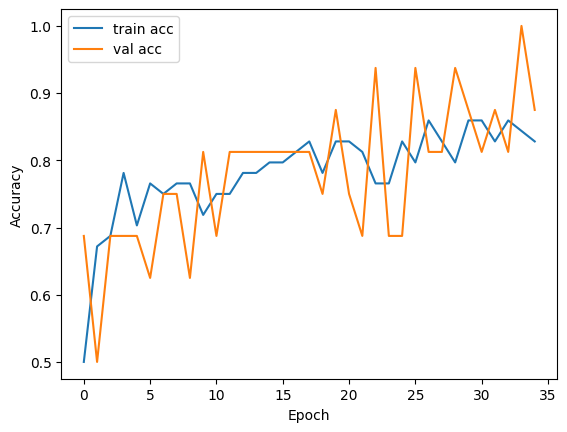

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Coordenadas de ángulos articulares como datos de entrada del modelo

### LSTM simple

In [ ]:
# ## Coordenadas de ángulos articulares como datos de entrada del modelo
X_correct = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_incorrect = np.load('../Data/Processed/wrong_push_ups_angles.npy')

# Creamos etiquetas
X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos y entrenamos el modelo LSTM
timesteps = X_train.shape[1]  # 200 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame

model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)

# Evaluamos el modelo en el conjunto de prueba
loss, acc = model.evaluate(X_test, y_test)
print("==="*10)
print(f"Test Accuracy: {acc:.2f}")
print("==="*10)

Epoch 1/40


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5938 - loss: 0.6590 - val_accuracy: 0.8750 - val_loss: 0.5928
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8906 - loss: 0.5514 - val_accuracy: 0.8125 - val_loss: 0.4963
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8906 - loss: 0.5063 - val_accuracy: 0.8125 - val_loss: 0.4891
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9375 - loss: 0.4800 - val_accuracy: 0.8750 - val_loss: 0.4894
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9375 - loss: 0.4452 - val_accuracy: 0.8750 - val_loss: 0.4434
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9375 - loss: 0.4198 - val_accuracy: 0.8125 - val_loss: 0.4132
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9375 - loss: 0.3990 - val_accuracy: 0.8750 - val_loss: 0.3931
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9375 - loss: 0.3690 - val_accuracy: 0.8750 - val_loss: 0.3560
Epoch 9/40

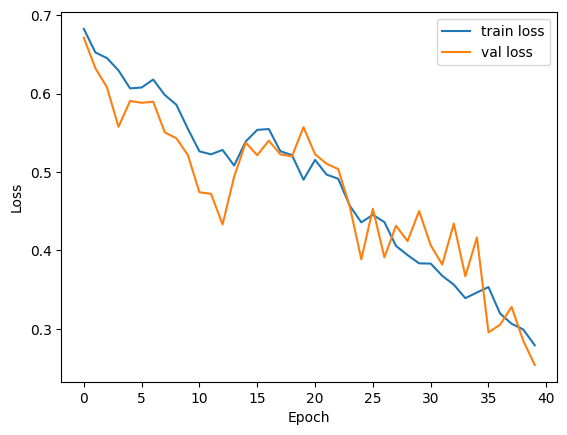

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

LSTM con output space de 128 

In [ ]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(128, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)

# Evaluamos el modelo en el conjunto de prueba
loss, acc = model.evaluate(X_test, y_test)
print("==="*10)
print(f"Test Accuracy: {acc:.2f}")
print("==="*10)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6562 - loss: 0.6477 - val_accuracy: 0.6250 - val_loss: 0.6104
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7031 - loss: 0.5931 - val_accuracy: 0.9375 - val_loss: 0.5438
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7031 - loss: 0.6368 - val_accuracy: 1.0000 - val_loss: 0.4544
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8750 - loss: 0.5034 - val_accuracy: 0.8750 - val_loss: 0.5448
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8594 - loss: 0.4794 - val_accuracy: 0.9375 - val_loss: 0.4315
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9219 - loss: 0.4433 - val_accuracy: 0.9375 - val_loss: 0.3657
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8906 - loss: 0.4220 - val_accuracy: 0.8750 - val_loss: 0.4185
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8438 - loss: 0.4362 - val_accuracy: 0.8750 - val_loss: 0.3638

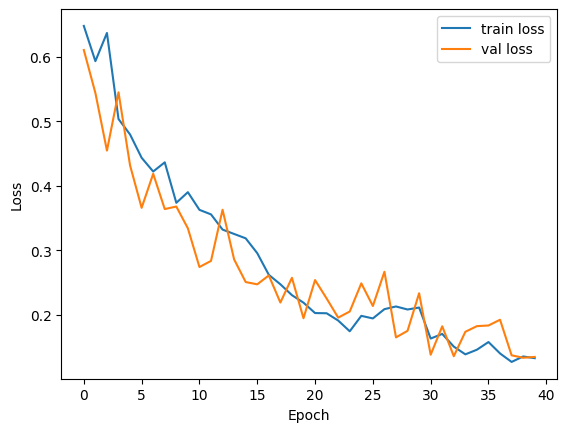

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

LSTM con espacio de salida de 128 y dos capas 

In [29]:
tf.random.set_seed(42)
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(128, return_sequences=True))  # 128 unidades LSTM, solo devolvemos la última salida
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)

# Evaluamos el modelo en el conjunto de prueba
loss, acc = model.evaluate(X_test, y_test)
print("==="*10)
print(f"Test Accuracy: {acc:.2f}")
print("==="*10)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.6719 - loss: 0.6675 - val_accuracy: 0.8125 - val_loss: 0.6091
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7969 - loss: 0.5943 - val_accuracy: 0.8125 - val_loss: 0.5665
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7656 - loss: 0.5676 - val_accuracy: 0.8125 - val_loss: 0.4881
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8750 - loss: 0.4651 - val_accuracy: 0.9375 - val_loss: 0.3784
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8906 - loss: 0.4279 - val_accuracy: 0.8750 - val_loss: 0.2988
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9531 - loss: 0.2485 - val_accuracy: 0.8750 - val_loss: 0.2844
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8594 - loss: 0.3591 - val_accuracy: 0.8750 - val_loss: 0.3443
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9375 - loss: 0.2381 - val_accuracy: 1.0000 - val_loss:

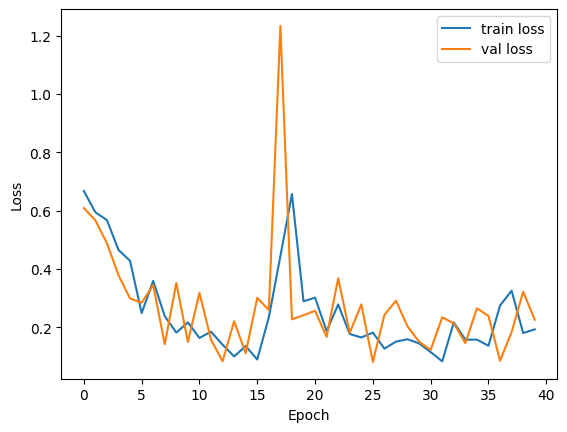

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Vamos a probar con validación cruzada

In [35]:
# Vamos a probar con validación cruzada

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


# Hiperparámetros para el entrenamiento
N_SPLITS = 5
EPOCHS = 40
BATCH_SIZE = 16

# Inicializar la validación cruzada
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lista para almacenar las métricas de cada pliegue
fold_accuracies = []
fold_losses = []
fold_histories = []

# ==============================================================================
## 2. Definición del Modelo (Función)
# ==============================================================================
# Definimos una función para crear y compilar el modelo
# Esto asegura que reiniciamos los pesos en cada pliegue
def create_lstm_model(timesteps, features):
    """Crea y compila el modelo LSTM."""
    model = Sequential()
    # input_shape lo definimos aquí usando los timesteps y features
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Obtenemos las dimensiones de tus datos de entrenamiento para el input_shape
# (Si X_train es un array de numpy):
try:
    _, timesteps, features = X_train.shape
except AttributeError:
    print("Por favor, asegúrate de que X_train está cargado como un array numpy con 3 dimensiones.")
    exit()

# ==============================================================================
## 3. Bucle de Entrenamiento con K-Fold
# ==============================================================================

print(f"Iniciando la validación cruzada de {N_SPLITS} pliegues...")
print("==="*15)

fold_n = 1
# Iteramos sobre los índices de entrenamiento y validación generados por KFold
for train_index, val_index in kf.split(X_train):
    print(f"| Entrenando Pliegue {fold_n}/{N_SPLITS}...")

    # Dividir los datos para el pliegue actual
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Crear una nueva instancia del modelo para garantizar pesos aleatorios
    model = create_lstm_model(timesteps, features)

    # Entrenar el modelo
    model.fit(
        X_train_fold, y_train_fold,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0 # No mostrar el output de cada epoch
    )

    fold_histories.append(history.history)

    # Evaluar el modelo en el conjunto de validación de este pliegue
    loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"| Precisión de Validación (Pliegue {fold_n}): {acc:.4f} | Pérdida: {loss:.4f}")

    # Guardar las métricas
    fold_accuracies.append(acc)
    fold_losses.append(loss)
    fold_n += 1

print("==="*15)


## 4. Resultados Finales

# Calcular la precisión media de la validación cruzada
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f" Validación Cruzada Completada con {N_SPLITS} Pliegues.")
print(f"| Precisión Media de Validación: **{mean_acc:.4f}**")
print(f"| Desviación Estándar de la Precisión: **{std_acc:.4f}**")
print("==="*15)

# Opcional: Entrenar el modelo final con todos los datos de entrenamiento
# y evaluar en X_test, si tienes uno separado.


Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8125 | Pérdida: 0.3375
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8750 | Pérdida: 0.2255
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9375 | Pérdida: 0.2692
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9375 | Pérdida: 0.1986
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 1.0000 | Pérdida: 0.0788
 Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9125**
| Desviación Estándar de la Precisión: **0.0637**


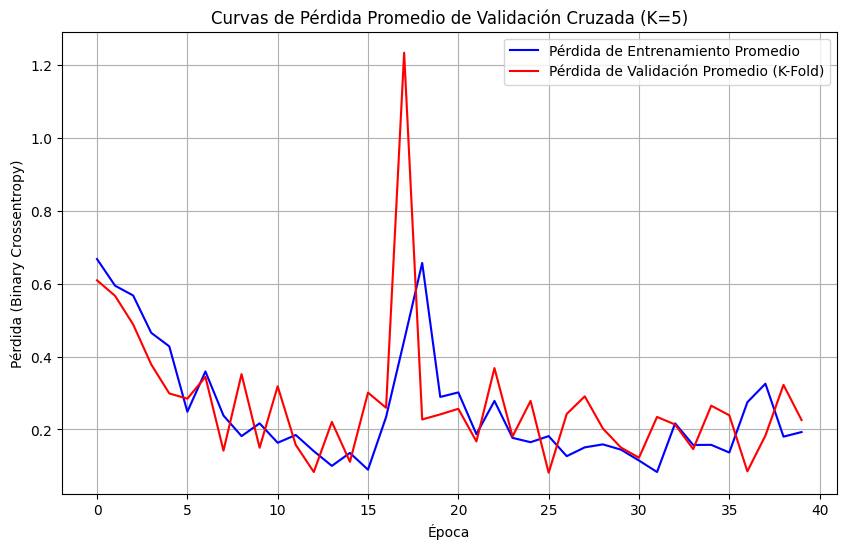

In [34]:
import matplotlib.pyplot as plt

## Cálculo del Promedio de las Curvas de Pérdida
# ----------------------------------------------------

# Inicializar arrays para almacenar las pérdidas de cada pliegue
num_epochs = EPOCHS
all_train_loss = np.zeros((N_SPLITS, num_epochs))
all_val_loss = np.zeros((N_SPLITS, num_epochs))

# Llenar los arrays con los datos de las historias
for i, hist in enumerate(fold_histories):
    all_train_loss[i] = hist['loss']
    all_val_loss[i] = hist['val_loss']

# Calcular la media y la desviación estándar
mean_train_loss = np.mean(all_train_loss, axis=0)
std_train_loss = np.std(all_train_loss, axis=0)
mean_val_loss = np.mean(all_val_loss, axis=0)
std_val_loss = np.std(all_val_loss, axis=0)

## Generación del Gráfico
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# Trazar la pérdida de entrenamiento promedio
plt.plot(mean_train_loss, label='Pérdida de Entrenamiento Promedio', color='blue')
# Trazar la banda de desviación estándar de entrenamiento
plt.fill_between(range(num_epochs), 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.1)

# Trazar la pérdida de validación promedio
plt.plot(mean_val_loss, label='Pérdida de Validación Promedio (K-Fold)', color='red')
# Trazar la banda de desviación estándar de validación
plt.fill_between(range(num_epochs), 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.1)

plt.title('Curvas de Pérdida Promedio de Validación Cruzada (K=5)')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

Vamos a probar con 15 épocas

In [43]:
# Vamos a probar con validación cruzada

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


# Hiperparámetros para el entrenamiento
N_SPLITS = 5
EPOCHS = 15
BATCH_SIZE = 16

# Inicializar la validación cruzada
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lista para almacenar las métricas de cada pliegue
fold_accuracies = []
fold_losses = []
fold_histories = []

# ==============================================================================
## 2. Definición del Modelo (Función)
# ==============================================================================
# Definimos una función para crear y compilar el modelo
# Esto asegura que reiniciamos los pesos en cada pliegue
def create_lstm_model(timesteps, features):
    """Crea y compila el modelo LSTM."""
    model = Sequential()
    # input_shape lo definimos aquí usando los timesteps y features
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Obtenemos las dimensiones de tus datos de entrenamiento para el input_shape
# (Si X_train es un array de numpy):
try:
    _, timesteps, features = X_train.shape
except AttributeError:
    print("Por favor, asegúrate de que X_train está cargado como un array numpy con 3 dimensiones.")
    exit()

# ==============================================================================
## 3. Bucle de Entrenamiento con K-Fold
# ==============================================================================

print(f"Iniciando la validación cruzada de {N_SPLITS} pliegues...")
print("==="*15)

fold_n = 1
# Iteramos sobre los índices de entrenamiento y validación generados por KFold
for train_index, val_index in kf.split(X_train):
    print(f"| Entrenando Pliegue {fold_n}/{N_SPLITS}...")

    # Dividir los datos para el pliegue actual
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Crear una nueva instancia del modelo para garantizar pesos aleatorios
    model = create_lstm_model(timesteps, features)

    # Entrenar el modelo
    model.fit(
        X_train_fold, y_train_fold,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0 # No mostrar el output de cada epoch
    )

    fold_histories.append(history.history)

    # Evaluar el modelo en el conjunto de validación de este pliegue
    loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"| Precisión de Validación (Pliegue {fold_n}): {acc:.4f} | Pérdida: {loss:.4f}")

    # Guardar las métricas
    fold_accuracies.append(acc)
    fold_losses.append(loss)
    fold_n += 1

print("==="*15)


## 4. Resultados Finales

# Calcular la precisión media de la validación cruzada
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f" Validación Cruzada Completada con {N_SPLITS} Pliegues.")
print(f"| Precisión Media de Validación: **{mean_acc:.4f}**")
print(f"| Desviación Estándar de la Precisión: **{std_acc:.4f}**")
print("==="*15)

# Opcional: Entrenar el modelo final con todos los datos de entrenamiento
# y evaluar en X_test, si tienes uno separado.


Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8750 | Pérdida: 0.3587
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8750 | Pérdida: 0.2898
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9375 | Pérdida: 0.3545
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9375 | Pérdida: 0.2838
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 1.0000 | Pérdida: 0.2325
 Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9250**
| Desviación Estándar de la Precisión: **0.0468**


In [42]:
import matplotlib.pyplot as plt

## Cálculo del Promedio de las Curvas de Pérdida
# ----------------------------------------------------

# Inicializar arrays para almacenar las pérdidas de cada pliegue
num_epochs = 15
all_train_loss = np.zeros((N_SPLITS, num_epochs))
all_val_loss = np.zeros((N_SPLITS, num_epochs))

# Llenar los arrays con los datos de las historias
for i, hist in enumerate(fold_histories):
    all_train_loss[i] = hist['loss']
    all_val_loss[i] = hist['val_loss']

# Calcular la media y la desviación estándar
mean_train_loss = np.mean(all_train_loss, axis=0)
std_train_loss = np.std(all_train_loss, axis=0)
mean_val_loss = np.mean(all_val_loss, axis=0)
std_val_loss = np.std(all_val_loss, axis=0)

## Generación del Gráfico
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# Trazar la pérdida de entrenamiento promedio
plt.plot(mean_train_loss, label='Pérdida de Entrenamiento Promedio', color='blue')
# Trazar la banda de desviación estándar de entrenamiento
plt.fill_between(range(num_epochs), 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.1)

# Trazar la pérdida de validación promedio
plt.plot(mean_val_loss, label='Pérdida de Validación Promedio (K-Fold)', color='red')
# Trazar la banda de desviación estándar de validación
plt.fill_between(range(num_epochs), 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.1)

plt.title('Curvas de Pérdida Promedio de Validación Cruzada (K=5)')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

ValueError: could not broadcast input array from shape (40,) into shape (15,)